[Step 1/4] Loading Dataset...
Sensor Dataset Loaded Successfully!
Sensor Shape : (144036, 32)

Label Dataset Loaded Successfully!
Label Shape : (144036, 14)

Filtering Sensor Signals...
Signal Filtering Completed!

Extracting Features...
Total Extracted Samples : 1125

ML Dataset Shape : (1125, 20)
Condition Classes: ['Bad' 'Good' 'Regular']
Encoded Labels: [0 1 2]
Data Split Completed!

[Step 2/4] Training ML Models...

Condition: Decision Tree
              precision    recall  f1-score   support

         Bad       0.61      0.54      0.57        37
        Good       0.97      0.98      0.97        88
     Regular       0.83      0.86      0.85       100

    accuracy                           0.85       225
   macro avg       0.80      0.79      0.80       225
weighted avg       0.85      0.85      0.85       225


Condition: Random Forest
              precision    recall  f1-score   support

         Bad       0.71      0.41      0.52        37
        Good       0.98      1.00 

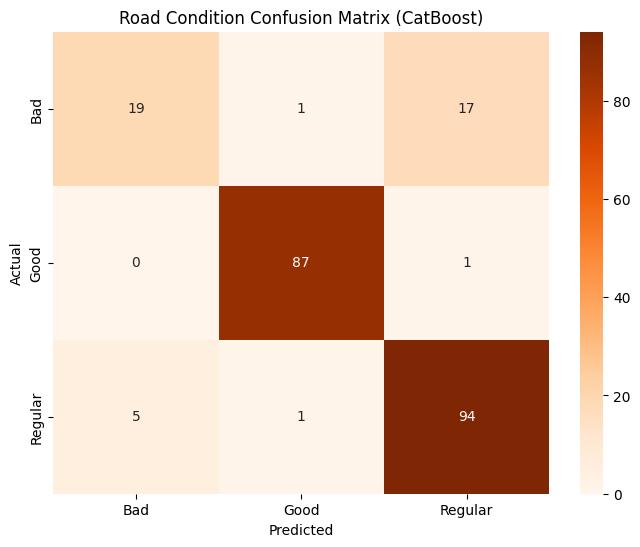

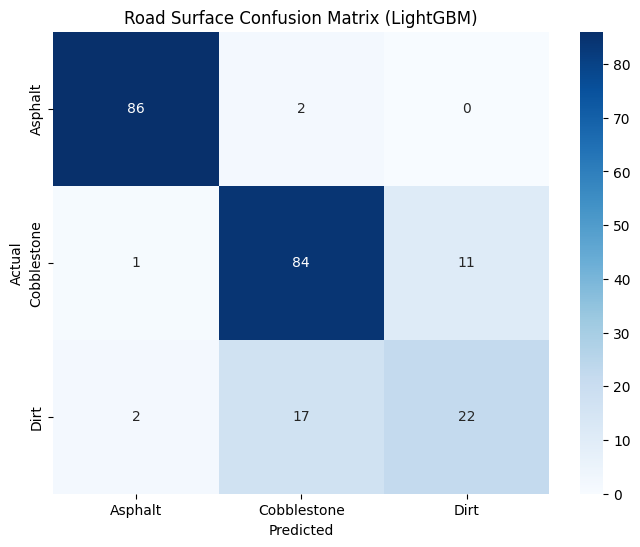


Enter 18 feature values:
mean_z: 0.03
std_z:  0.92
rms_x: 0.88
rms_y: 0.95
rms_z: 1.15
peak_z: 2.80
variance_z: 0.85
xz_ratio: 0.77
skew_z: 0.18
kurtosis_z: 2.65
energy_z: 169.28
max_z: 2.80
min_z: -2.42
fft_mean: 3.48
fft_max: 20.35
fft_std: 4.52
speed_kmh: 42
total_vibration: 101.7

ROAD CONDITION : Good
ROAD SURFACE   : Asphalt


In [6]:

# INSTALL REQUIRED LIBRARIES


!pip install -q catboost lightgbm xgboost imbalanced-learn


# IMPORT LIBRARIES


import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# LOAD DATASETS


print("==================================================")
print("[Step 1/4] Loading Dataset...")
print("==================================================")

sensor_path = "/content/dataset_gps_mpu_left.csv"
label_path = "/content/dataset_labels.csv"

df_sensor = pd.read_csv(sensor_path)
df_label = pd.read_csv(label_path)

print("Sensor Dataset Loaded Successfully!")
print("Sensor Shape :", df_sensor.shape)

print("\nLabel Dataset Loaded Successfully!")
print("Label Shape :", df_label.shape)


condition_labels = []

for _, row in df_label.iterrows():

    if (
        row["bad_road_left"] == 1
        or row["bad_road_right"] == 1
    ):
        condition_labels.append("Bad")

    elif (
        row["regular_road_left"] == 1
        or row["regular_road_right"] == 1
    ):
        condition_labels.append("Regular")

    else:
        condition_labels.append("Good")

df_label["road_condition"] = condition_labels


surface_labels = []

for _, row in df_label.iterrows():

    if row["dirt_road"] == 1:
        surface_labels.append("Dirt")

    elif row["cobblestone_road"] == 1:
        surface_labels.append("Cobblestone")

    else:
        surface_labels.append("Asphalt")

df_label["road_surface"] = surface_labels





# HIGH PASS FILTER


def butter_highpass_filter(
    data,
    cutoff=1.5,
    fs=50.0,
    order=5,
):

    nyq = 0.5 * fs

    normal_cutoff = cutoff / nyq

    b, a = butter(
        order,
        normal_cutoff,
        btype="high",
        analog=False,
    )

    return filtfilt(b, a, data)


# SENSOR SIGNALS


print("\nFiltering Sensor Signals...")

acc_x = df_sensor["acc_x_dashboard"].values
acc_y = df_sensor["acc_y_dashboard"].values
acc_z = df_sensor["acc_z_dashboard"].values

fs = 50.0

filtered_x = butter_highpass_filter(acc_x, fs=fs)
filtered_y = butter_highpass_filter(acc_y, fs=fs)
filtered_z = butter_highpass_filter(acc_z, fs=fs)

print("Signal Filtering Completed!")


# FEATURE EXTRACTION


print("\nExtracting Features...")

window_size = 128
overlap = 128

all_features = []

for i in range(0, len(df_sensor) - window_size, overlap):

    w_x = filtered_x[i : i + window_size]
    w_y = filtered_y[i : i + window_size]
    w_z = filtered_z[i : i + window_size]

    w_speed = df_sensor["speed"].iloc[
        i : i + window_size
    ].mean()

    condition_label = df_label[
        "road_condition"
    ].iloc[i]

    surface_label = df_label[
        "road_surface"
    ].iloc[i]

    # RMS FEATURES
    rms_x = np.sqrt(np.mean(w_x**2))
    rms_y = np.sqrt(np.mean(w_y**2))
    rms_z = np.sqrt(np.mean(w_z**2))

    # BASIC FEATURES
    mean_z = np.mean(w_z)
    std_z = np.std(w_z)

    peak_z = np.max(np.abs(w_z))
    variance_z = np.var(w_z)

    xz_ratio = rms_x / (rms_z + 1e-6)

    # EXTRA FEATURES
    skew_z = skew(w_z)
    kurt_z = kurtosis(w_z)

    energy_z = np.sum(w_z**2)

    max_z = np.max(w_z)
    min_z = np.min(w_z)

    # FFT FEATURES
    fft_z = np.abs(
        np.fft.fft(w_z)
    )[: window_size // 2]

    fft_mean = np.mean(fft_z)
    fft_max = np.max(fft_z)
    fft_std = np.std(fft_z)

    all_features.append({

        "mean_z": mean_z,
        "std_z": std_z,

        "rms_x": rms_x,
        "rms_y": rms_y,
        "rms_z": rms_z,

        "peak_z": peak_z,
        "variance_z": variance_z,
        "xz_ratio": xz_ratio,

        "skew_z": skew_z,
        "kurtosis_z": kurt_z,
        "energy_z": energy_z,

        "max_z": max_z,
        "min_z": min_z,

        "fft_mean": fft_mean,
        "fft_max": fft_max,
        "fft_std": fft_std,

        "speed_kmh": w_speed * 3.6,

        "total_vibration": np.sum(
            np.abs(w_z)
        ),

        "road_condition": condition_label,
        "road_surface": surface_label

    })

print(
    "Total Extracted Samples :",
    len(all_features)
)

# MACHINE LEARNING DATAFRAME


df_ml = pd.DataFrame(all_features)

print("\nML Dataset Shape :", df_ml.shape)


# FEATURES & TARGET

feature_cols = [

    "mean_z",
    "std_z",

    "rms_x",
    "rms_y",
    "rms_z",

    "peak_z",
    "variance_z",
    "xz_ratio",

    "skew_z",
    "kurtosis_z",

    "energy_z",
    "max_z",
    "min_z",

    "fft_mean",
    "fft_max",
    "fft_std",

    "speed_kmh",

    "total_vibration",
]

X = df_ml[feature_cols]

condition_encoder = LabelEncoder()

y_condition = condition_encoder.fit_transform(
    df_ml["road_condition"]
)

print("Condition Classes:", condition_encoder.classes_)
print("Encoded Labels:", np.unique(y_condition))

surface_encoder = LabelEncoder()

y_surface = surface_encoder.fit_transform(
    df_ml["road_surface"]
)




# TRAIN TEST SPLIT


# Road Condition
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_condition,
    test_size=0.2,
    random_state=42,
    stratify=y_condition
)

# Road Surface
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y_surface,
    test_size=0.2,
    random_state=42,
    stratify=y_surface
)

print("Data Split Completed!")


# MODEL TRAINING


print("\n==================================================")
print("[Step 2/4] Training ML Models...")
print("==================================================")

models = {

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_split=2,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        depth=8,
        learning_rate=0.03,
        random_state=42,
        verbose=0
    )
}

accuracy_results_condition = {}
trained_models_condition = {}

accuracy_results_surface = {}
trained_models_surface = {}

# TRAIN & EVALUATE
# =========================
# ROAD CONDITION
# =========================

for name, model in models.items():

    model_copy = clone(model)

    model_copy.fit(X_train_c, y_train_c)

    pred = model_copy.predict(X_test_c)

    acc = accuracy_score(y_test_c, pred)

    accuracy_results_condition[name] = acc

    trained_models_condition[name] = model_copy

    print("\nCondition:", name)

    print(
        classification_report(
            y_test_c,
            pred,
            target_names=condition_encoder.classes_
        )
    )

# =========================
# ROAD SURFACE
# =========================

for name, model in models.items():

    model_copy = clone(model)

    model_copy.fit(X_train_s, y_train_s)

    pred = model_copy.predict(X_test_s)

    acc = accuracy_score(y_test_s, pred)

    accuracy_results_surface[name] = acc

    trained_models_surface[name] = model_copy

    print("\nSurface:", name)

    print(
        classification_report(
            y_test_s,
            pred,
            target_names=surface_encoder.classes_
        )
    )


# PERFORMANCE SUMMARY

print("\n==================================================")
print("ROAD CONDITION RESULTS")
print("==================================================")

for model_name, score in accuracy_results_condition.items():

    print(
        f"{model_name} --> {score*100:.2f}%"
    )

print("\n==================================================")
print("ROAD SURFACE RESULTS")
print("==================================================")

for model_name, score in accuracy_results_surface.items():

    print(
        f"{model_name} --> {score*100:.2f}%"
    )


# ==========================================
# BEST CONDITION MODEL
# ==========================================

best_condition_name = max(
    accuracy_results_condition,
    key=accuracy_results_condition.get
)

best_condition_model = trained_models_condition[
    best_condition_name
]

print(
    "\nBest Condition Model :",
    best_condition_name
)

print(
    "Best Condition Accuracy :",
    round(
        accuracy_results_condition[
            best_condition_name
        ] * 100,
        2
    ),
    "%"
)


# ==========================================
# BEST SURFACE MODEL
# ==========================================

best_surface_name = max(
    accuracy_results_surface,
    key=accuracy_results_surface.get
)

best_surface_model = trained_models_surface[
    best_surface_name
]

print(
    "\nBest Surface Model :",
    best_surface_name
)

print(
    "Best Surface Accuracy :",
    round(
        accuracy_results_surface[
            best_surface_name
        ] * 100,
        2
    ),
    "%"
)



# CONFUSION MATRIX

# ==========================================
# ROAD CONDITION CONFUSION MATRIX
# ==========================================

best_condition_preds = best_condition_model.predict(
    X_test_c
)

print("\nBest Model:", best_condition_name)

print("\nClassification Report:")
print(classification_report(
    y_test_c,
    best_condition_preds,
    target_names=condition_encoder.classes_
))

cm = confusion_matrix(y_test_c, best_condition_preds)

print("\nConfusion Matrix:")
print(cm)



plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=condition_encoder.classes_,
    yticklabels=condition_encoder.classes_,
)

plt.title(
    f"Road Condition Confusion Matrix ({best_condition_name})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ==========================================
# ROAD SURFACE CONFUSION MATRIX
# ==========================================

best_surface_preds = best_surface_model.predict(
    X_test_s
)

cm = confusion_matrix(
    y_test_s,
    best_surface_preds
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=surface_encoder.classes_,
    yticklabels=surface_encoder.classes_,
)

plt.title(
    f"Road Surface Confusion Matrix ({best_surface_name})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_from_input():

    print("\nEnter 18 feature values:")

    mean_z = float(input("mean_z: "))
    std_z = float(input("std_z: "))

    rms_x = float(input("rms_x: "))
    rms_y = float(input("rms_y: "))
    rms_z = float(input("rms_z: "))

    peak_z = float(input("peak_z: "))
    variance_z = float(input("variance_z: "))
    xz_ratio = float(input("xz_ratio: "))

    skew_z = float(input("skew_z: "))
    kurtosis_z = float(input("kurtosis_z: "))
    energy_z = float(input("energy_z: "))

    max_z = float(input("max_z: "))
    min_z = float(input("min_z: "))

    fft_mean = float(input("fft_mean: "))
    fft_max = float(input("fft_max: "))
    fft_std = float(input("fft_std: "))

    speed_kmh = float(input("speed_kmh: "))
    total_vibration = float(input("total_vibration: "))

    user_input = pd.DataFrame([{

        "mean_z": mean_z,
        "std_z": std_z,

        "rms_x": rms_x,
        "rms_y": rms_y,
        "rms_z": rms_z,

        "peak_z": peak_z,
        "variance_z": variance_z,
        "xz_ratio": xz_ratio,

        "skew_z": skew_z,
        "kurtosis_z": kurtosis_z,
        "energy_z": energy_z,

        "max_z": max_z,
        "min_z": min_z,

        "fft_mean": fft_mean,
        "fft_max": fft_max,
        "fft_std": fft_std,

        "speed_kmh": speed_kmh,
        "total_vibration": total_vibration

    }])

    # ROAD CONDITION

    condition_pred = best_condition_model.predict(
        user_input
    )

    condition_result = (
        condition_encoder.inverse_transform(
            condition_pred
        )
    )

    # ROAD SURFACE

    surface_pred = best_surface_model.predict(
        user_input
    )

    surface_result = (
        surface_encoder.inverse_transform(
            surface_pred
        )
    )

    print("\n===================================")
    print("ROAD CONDITION :", condition_result[0])
    print("ROAD SURFACE   :", surface_result[0])
    print("===================================")


# RUN PREDICTION

predict_from_input()